In [ ]:
import zipfile
with zipfile.ZipFile('archive (3).zip','r') as zip_ref:
  zip_ref.extractall()

In [ ]:
import os
os.listdir()

['.config', 'netflix_titles.csv', 'archive (3).zip', 'sample_data']

In [ ]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df = df.dropna(subset=['date_added','rating'])

In [ ]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')

In [ ]:
df['date_added'] = df['date_added'].str.strip()

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [ ]:
df = df.dropna(subset=['date_added'])

In [ ]:
df['date_added'].dt.year.value_counts()

,count
date_added,
2019,2016
2020,1879
2018,1648
2021,1498
2017,1186
2016,428
2015,82
2014,24
2011,13


Total Titles: 8793
Total Movies: 6129
Total TV Shows: 2664


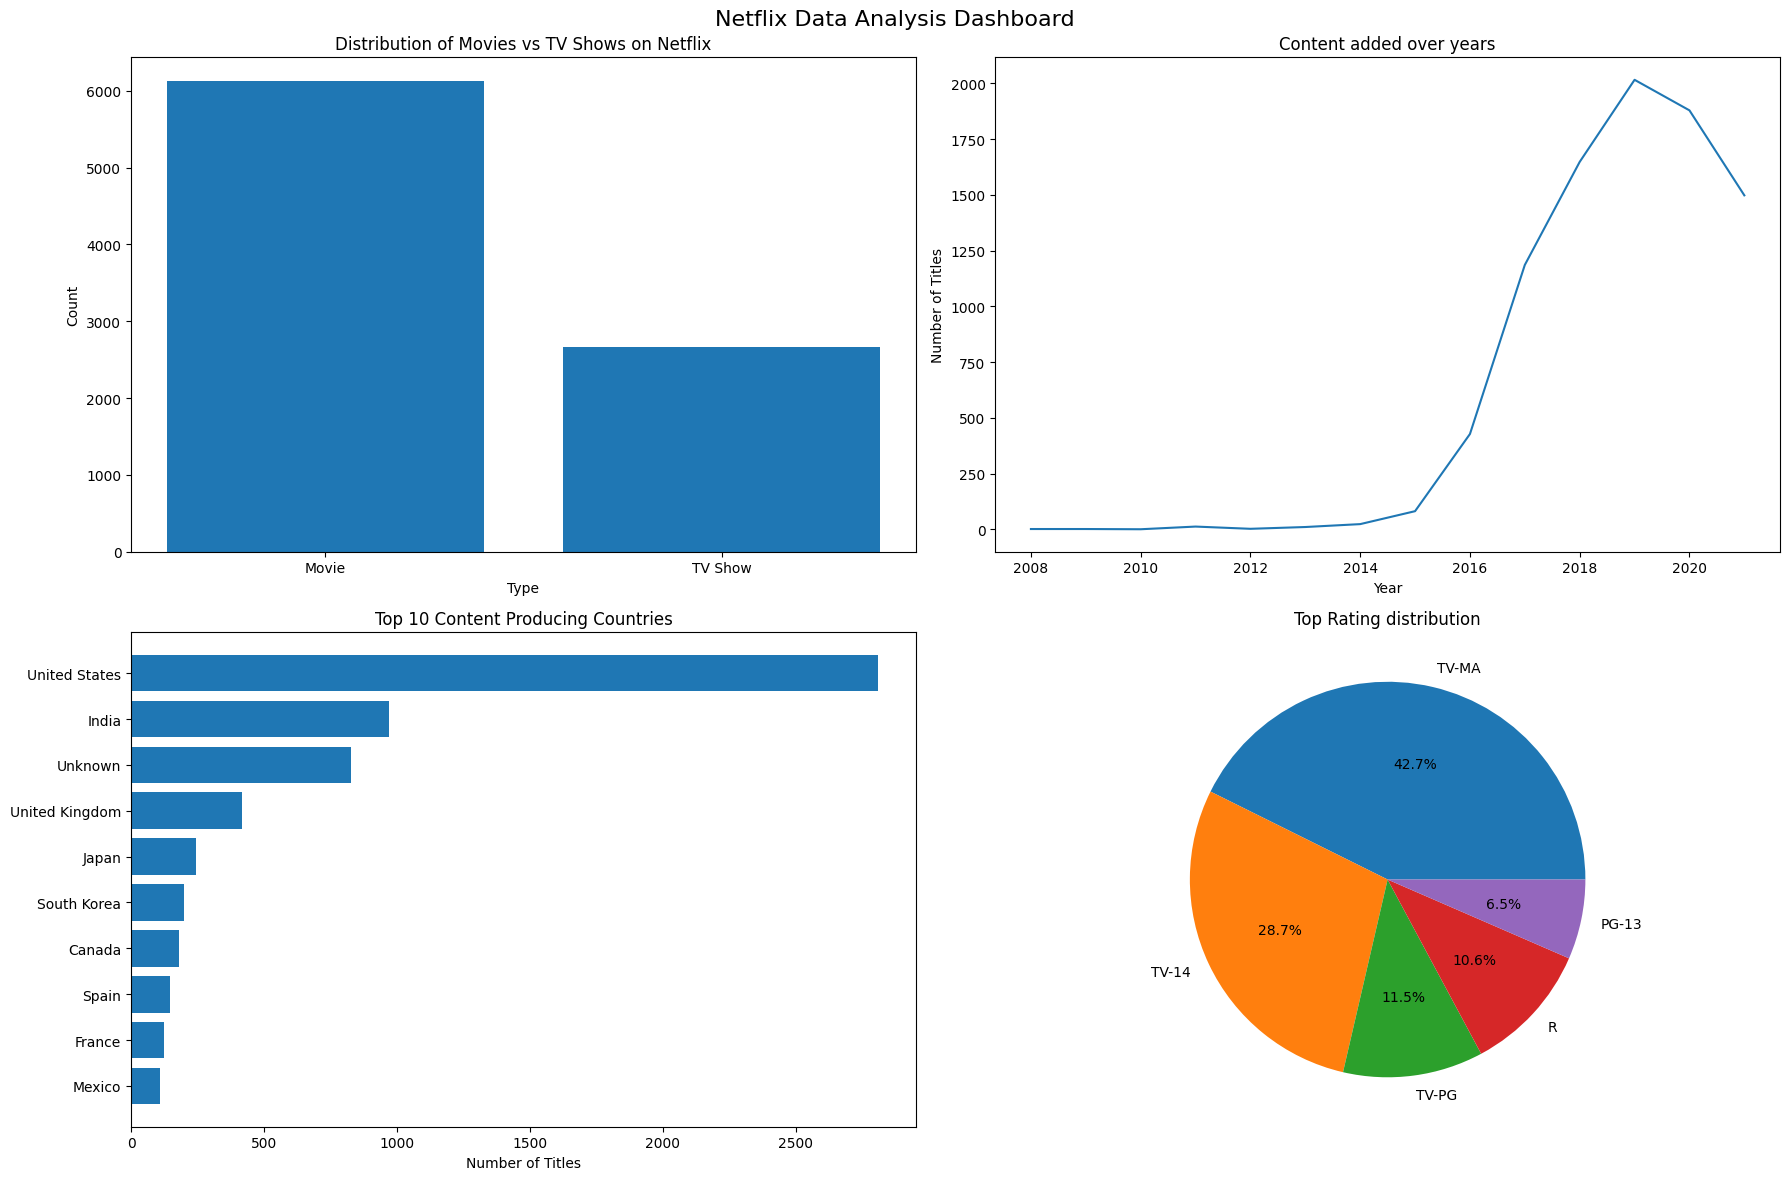

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, figsize=(18, 12))

#----chart:1 Movies Vs TV shows-----
type_count = df['type'].value_counts()
axes[0,0].bar(type_count.index, type_count.values)
axes[0,0].set_title('Distribution of Movies vs TV Shows on Netflix')
axes[0,0].set_xlabel('Type')
axes[0,0].set_ylabel('Count')

#-----chart 2: Content added over years----
year_added = df['date_added'].dt.year.value_counts().sort_index()
axes[0,1].plot(year_added.index, year_added.values)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Number of Titles')
axes[0,1].set_title('Content added over years')

#-----chart 3: Top 10 Countries-----
top_countries = df['country'].value_counts().head(10)
axes[1,0].barh(top_countries.index, top_countries.values)
axes[1,0].set_xlabel('Number of Titles')
axes[1,0].invert_yaxis()
axes[1,0].set_title('Top 10 Content Producing Countries')

#-----chart 4: Rating distribution----
rating_counts = df['rating'].value_counts().head(5)
axes[1,1].pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Top Rating distribution')

print('Total Titles:', len(df))
print('Total Movies:',len(df[df['type']=='Movie']))
print('Total TV Shows:',len(df[df['type']=='TV Show']))

#-----Main title---
fig.suptitle('Netflix Data Analysis Dashboard', fontsize=16)

plt.tight_layout()
plt.savefig('netflix_dashboard.png',bbox_inches='tight',dpi=300)

plt.show()